# Simulating Gaussian Brownian Motion using Bernoulli Distribution

In [4]:
import numpy as np
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2

In [ ]:
def simulate_brownian_motion(T, n):
    """
    T: Total time (e.g., 1 year)
    n: Total steps over T (e.g., 252 trading days)
    Returns: Simulated Brownian motion path at discrete time points
    """
    dt = T / n

    # Generate iid steps using Bernoulli flips
    steps = np.random.choice([-1, 1], size=n)
    # Scale the steps by sqrt(dt) to get the Brownian increments
    increments = steps * np.sqrt(dt)
    # Compute the path (cumualtive sum)
    # Bn(t) = S[nt] / sqrt(n)
    path = np.cumsum(increments)

    # Prepend 0 to start at B(0) = 0
    return np.insert(path, 0, 0) 

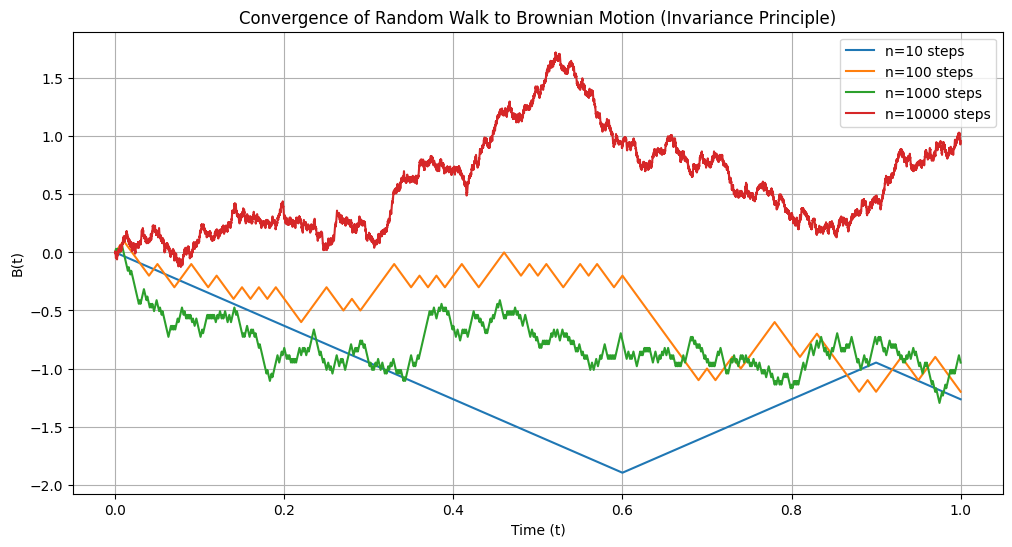

In [11]:
T = 1.0
steps_list = [10, 100, 1000, 10000]
time_axis = np.linspace(0, T, 10001)

plt.figure(figsize=(12, 6))

for n in steps_list:
    path = simulate_brownian_motion(T, n)
    plt.plot(np.linspace(0, T, n+1), path, label=f'n={n} steps')

plt.title("Convergence of Random Walk to Brownian Motion (Invariance Principle)")
plt.xlabel("Time (t)")
plt.ylabel("B(t)")
plt.legend()
plt.grid(True)
plt.show()